# Bayesian Linear Regression with `brms`

## Overview

`brms` (Bürkner 2017) is a high-level R interface to Stan that uses R's standard model formula syntax. It handles a very wide range of response distributions and link functions, supports multilevel models, and integrates with the `tidybayes` and `loo` packages.

**Workflow:**
1. Specify priors — `prior()` statements
2. Run prior predictive checks — verify priors are reasonable before seeing data
3. Fit the model — `brm()`
4. Check MCMC diagnostics — R-hat, ESS, trace plots
5. Posterior predictive check — does the model reproduce key data features?
6. Summarise and interpret — posterior means, credible intervals
7. Compare with frequentist results

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(brms)        # Bayesian regression via Stan
library(tidybayes)   # tidy posterior summaries and plots
library(patchwork)
library(broom.mixed) # tidy() for brms models

set.seed(42)

# ── Simulate invertebrate richness ~ nitrate + habitat ────────────────────────
n <- 120
reg_data <- tibble(
  habitat   = factor(rep(c("reference","restored","degraded"), each=n/3),
                     levels=c("reference","restored","degraded")),
  nitrate   = rnorm(n, mean=ifelse(habitat=="degraded", 5, 3), sd=1),
  richness  = round(
    25 +
    case_when(habitat=="reference" ~ 0, habitat=="restored" ~ -3, habitat=="degraded" ~ -8) +
    -2.5 * scale(nitrate)[,1] +
    rnorm(n, 0, 3)
  )
) %>%
  mutate(richness = pmax(richness, 1))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'brms' was built under R version 4.4.3"
Loading required package: Rcpp

Loading 'brms' package (version 2.2

---

## Step 1: Prior Specification

prior,class,coef,group,resp,dpar,nlpar,lb,ub,tag,source
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
,b,,,,,,,,,default
,b,habitatdegraded,,,,,,,,default
,b,habitatrestored,,,,,,,,default
,b,nitrate,,,,,,,,default
"student_t(3, 22, 5.9)",Intercept,,,,,,,,,default
"student_t(3, 0, 5.9)",sigma,,,,,,0,,,default


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


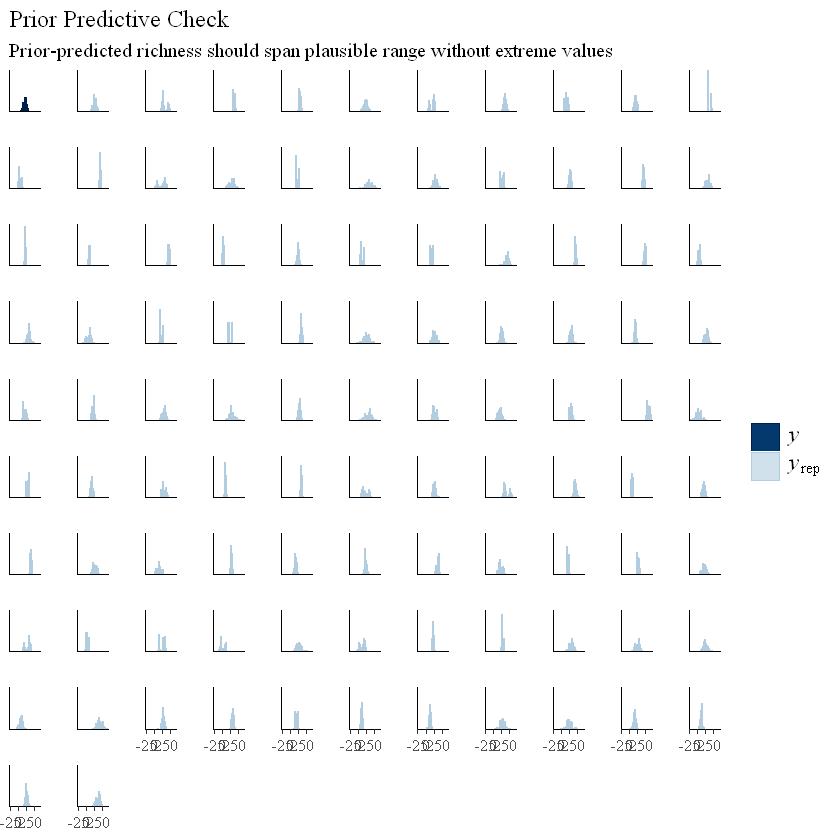

In [2]:
# ── Inspect default priors ────────────────────────────────────────────────────
get_prior(
  richness ~ nitrate + habitat,
  data   = reg_data,
  family = gaussian()
)
# brms uses weakly informative defaults; always inspect and consider adjusting

# ── Specify informative priors ────────────────────────────────────────────────
# Think in terms of the outcome scale:
#   richness is count ~ 15-35, so intercept ~ Normal(25, 10) is reasonable
#   nitrate effect: -1 to -5 species per unit change, so Normal(0, 3)
#   habitat effects: order of magnitude ~ 5-10 species, so Normal(0, 5)
#   sigma: must be positive; half-Normal(0, 5) or exponential(1)

my_priors <- c(
  prior(normal(25, 10),  class=Intercept),
  prior(normal(0, 3),    class=b, coef=nitrate),
  prior(normal(0, 5),    class=b, coef=habitatrestored),
  prior(normal(0, 5),    class=b, coef=habitatdegraded),
  prior(exponential(1),  class=sigma)
)

# ── Prior predictive check ────────────────────────────────────────────────────
# Fit with sample_prior="only" — no data used; shows what priors predict
m_prior <- brm(
  richness ~ nitrate + habitat,
  data         = reg_data,
  family       = gaussian(),
  prior        = my_priors,
  sample_prior = "only",
  chains=2, iter=2000, warmup=1000, cores=2,
  silent=2
)
brms::pp_check(m_prior, ndraws=100, type="hist") +
  labs(title="Prior Predictive Check",
       subtitle="Prior-predicted richness should span plausible range without extreme values")

---

## Step 2–3: Fit the Model

In [3]:
m_fit <- brm(
  richness ~ nitrate + habitat,
  data    = reg_data,
  family  = gaussian(),
  prior   = my_priors,
  chains  = 4,          # always run >= 4 chains
  iter    = 3000,
  warmup  = 1000,
  cores   = 4,          # parallel chains
  seed    = 42,
  silent  = 2
)
print(m_fit)
# Output:
#   Estimate: posterior mean
#   Est.Error: posterior SD
#   l-95% CI / u-95% CI: equal-tailed credible interval
#   Rhat: should be 1.00 (< 1.01 acceptable)
#   Bulk_ESS / Tail_ESS: effective sample size

 Family: gaussian 
  Links: mu = identity 
Formula: richness ~ nitrate + habitat 
   Data: reg_data (Number of observations: 120) 
  Draws: 4 chains, each with iter = 3000; warmup = 1000; thin = 1;
         total post-warmup draws = 8000

Regression Coefficients:
                Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept          31.89      0.81    30.29    33.47 1.00     8239     5965
nitrate            -2.15      0.24    -2.62    -1.69 1.00     6371     5512
habitatrestored    -2.10      0.59    -3.25    -0.94 1.00     8052     5547
habitatdegraded    -6.62      0.77    -8.15    -5.13 1.00     6348     6131

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma     2.68      0.17     2.37     3.05 1.00     8710     6009

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the potential
scale reduction factor on split chains (at

---

## Step 4: MCMC Diagnostics

Max R-hat: 1.0023  (should be < 1.01)
Min ESS ratio: 0.4462  (should be > 0.1)


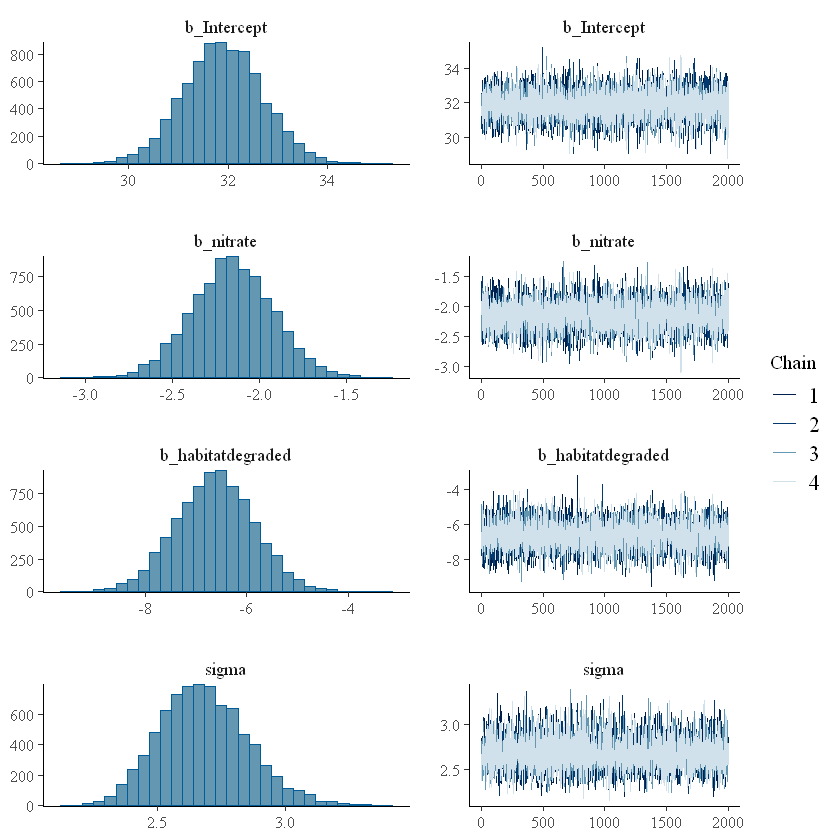

In [4]:
# Trace plots — all chains should mix well (caterpillar shape)
plot(m_fit, variable=c("b_Intercept","b_nitrate","b_habitatdegraded","sigma"))

# Summary diagnostics
rhat_vals <- brms::rhat(m_fit)
ess_vals  <- brms::neff_ratio(m_fit)
cat(sprintf("Max R-hat: %.4f  (should be < 1.01)\n", max(rhat_vals, na.rm=TRUE)))
cat(sprintf("Min ESS ratio: %.4f  (should be > 0.1)\n", min(ess_vals, na.rm=TRUE)))
# Full MCMC diagnostics: see mcmc_diagnostics.ipynb

---

## Step 5: Posterior Predictive Check

Note: in most cases the default test statistic 'mean' is too weak to detect anything of interest.

Note: in most cases the default test statistic 'mean' is too weak to detect anything of interest.

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


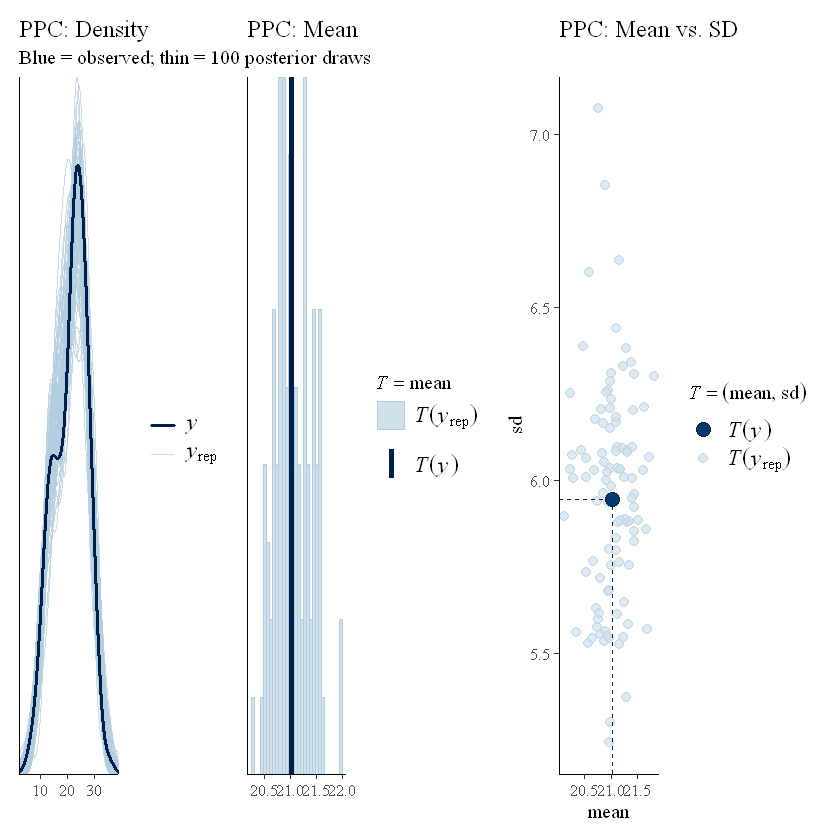

In [5]:
# PPC: simulate data from the fitted model and compare to observed
# If the model is adequate, simulated datasets should resemble the real data

p1 <- brms::pp_check(m_fit, ndraws=100, type="dens_overlay") +
  labs(title="PPC: Density", subtitle="Blue = observed; thin = 100 posterior draws")

p2 <- brms::pp_check(m_fit, ndraws=100, type="stat", stat="mean") +
  labs(title="PPC: Mean")

p3 <- brms::pp_check(m_fit, ndraws=100, type="stat_2d",
                     stat=c("mean","sd")) +
  labs(title="PPC: Mean vs. SD")

(p1 | p2 | p3)

---

## Step 6: Posterior Summary and Frequentist Comparison

In [6]:
# ── Posterior summaries (tidybayes) ───────────────────────────────────────────
post_summary <- tidybayes::gather_draws(
  m_fit, b_Intercept, b_nitrate, b_habitatrestored, b_habitatdegraded, sigma
) %>%
  group_by(.variable) %>%
  summarise(
    mean   = mean(.value),
    sd     = sd(.value),
    q2.5   = quantile(.value, 0.025),
    q97.5  = quantile(.value, 0.975),
    p_neg  = mean(.value < 0)   # P(effect < 0 | data)
  ) %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))
print(post_summary)

# ── Frequentist comparison (lm) ───────────────────────────────────────────────
freq_fit <- lm(richness ~ nitrate + habitat, data=reg_data)
cat("\nFrequentist lm results:\n")
print(broom::tidy(freq_fit, conf.int=TRUE)[,c("term","estimate","conf.low","conf.high","p.value")])
# With weakly informative priors and n=120, Bayesian and frequentist estimates
# should be very similar. Differences increase with smaller n or stronger priors.

# ── Posterior probability statements ─────────────────────────────────────────
draws_nitrate <- tidybayes::spread_draws(m_fit, b_nitrate)$b_nitrate
cat(sprintf("\nP(nitrate effect < -1 | data) = %.3f\n", mean(draws_nitrate < -1)))
cat(sprintf("P(nitrate effect < 0  | data) = %.3f\n", mean(draws_nitrate < 0)))

# A tibble: 5 × 6
  .variable          mean    sd  q2.5  q97.5 p_neg
  <chr>             <dbl> <dbl> <dbl>  <dbl> <dbl>
1 b_Intercept       31.9  0.809 30.3  33.5       0
2 b_habitatdegraded -6.62 0.771 -8.15 -5.13      1
3 b_habitatrestored -2.10 0.59  -3.25 -0.943     1
4 b_nitrate         -2.15 0.235 -2.62 -1.69      1
5 sigma              2.68 0.174  2.37  3.06      0

Frequentist lm results:
# A tibble: 4 × 5
  term            estimate conf.low conf.high  p.value
  <chr>              <dbl>    <dbl>     <dbl>    <dbl>
1 (Intercept)        31.9     30.3     33.5   2.50e-68
2 nitrate            -2.14    -2.61    -1.67  5.26e-15
3 habitatrestored    -2.17    -3.36    -0.980 4.50e- 4
4 habitatdegraded    -6.76    -8.30    -5.22  2.81e-14

P(nitrate effect < -1 | data) = 1.000
P(nitrate effect < 0  | data) = 1.000


---

## Visualising the Posterior

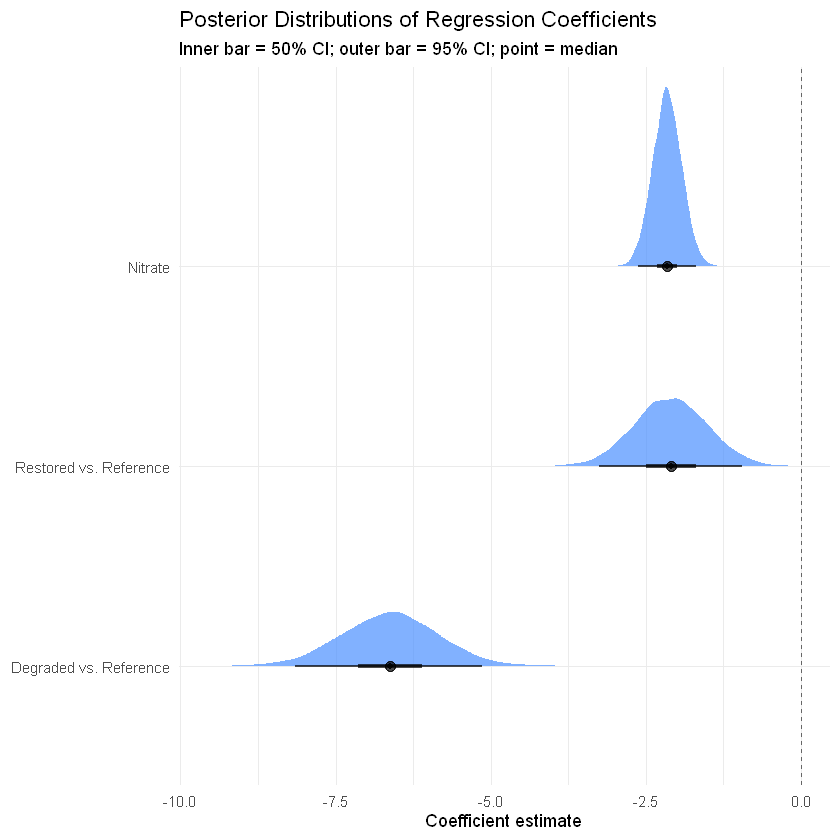

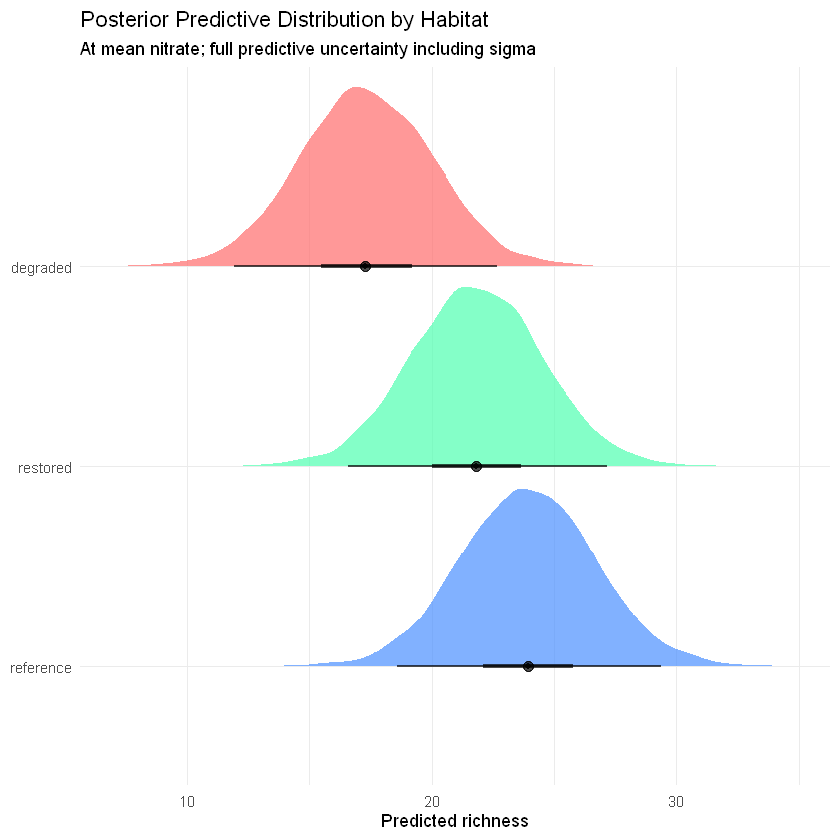

In [7]:
# ── Coefficient plot with posterior distributions ────────────────────────────
tidybayes::gather_draws(
  m_fit, b_nitrate, b_habitatrestored, b_habitatdegraded
) %>%
  ggplot(aes(x=.value, y=.variable)) +
  tidybayes::stat_halfeye(
    .width = c(0.50, 0.95),
    fill   = "#4a8fff", alpha=0.7
  ) +
  geom_vline(xintercept=0, linetype="dashed", color="gray40") +
  scale_y_discrete(
    labels=c(b_nitrate="Nitrate",
             b_habitatrestored="Restored vs. Reference",
             b_habitatdegraded="Degraded vs. Reference")
  ) +
  labs(title="Posterior Distributions of Regression Coefficients",
       subtitle="Inner bar = 50% CI; outer bar = 95% CI; point = median",
       x="Coefficient estimate", y=NULL) +
  theme_minimal()

# ── Posterior predictive distribution for new data ────────────────────────────
newdata <- tibble(
  habitat = factor(c("reference","restored","degraded"),
                   levels=levels(reg_data$habitat)),
  nitrate = mean(reg_data$nitrate)
)

predictions <- tidybayes::add_predicted_draws(m_fit, newdata=newdata)

ggplot(predictions, aes(x=.prediction, y=habitat, fill=habitat)) +
  tidybayes::stat_halfeye(.width=c(0.50,0.95), alpha=0.7) +
  scale_fill_manual(values=c(reference="#4a8fff",restored="#4fffb0",degraded="#ff6b6b")) +
  labs(title="Posterior Predictive Distribution by Habitat",
       subtitle="At mean nitrate; full predictive uncertainty including sigma",
       x="Predicted richness", y=NULL) +
  theme_minimal() + theme(legend.position="none")

---

## Common Pitfalls

**1. Using flat or improper priors without thought**  
Default `brms` priors are weakly informative, but `prior(flat)` or very wide priors like `Normal(0, 1000)` can cause sampling problems and poor estimates, especially for variance parameters. Think about the outcome scale and choose priors that rule out physically impossible values.

**2. Skipping the prior predictive check**  
Running `sample_prior="only"` before fitting takes seconds and can reveal priors that predict impossible outcomes (negative counts, probabilities > 1, absurdly large effects). This is the first step of the Bayesian workflow — see `bayesian_workflow.ipynb`.

**3. Reporting only the posterior mean**  
The power of Bayesian inference is the full posterior distribution. Report the posterior mean or median, the posterior SD, the credible interval, and, where relevant, the posterior probability of substantive hypotheses (e.g. `P(effect < 0 | data)`).

**4. Not running multiple chains**  
A single chain that appears to have converged may simply be stuck in one region of the posterior. Always run at least 4 independent chains and compare their R-hat values — see `mcmc_diagnostics.ipynb`.

**5. Treating `brms` as a black box**  
The formula syntax makes Bayesian regression accessible, but the defaults (priors, family, link function) need checking for each problem. Always inspect `get_prior()`, examine trace plots, and run posterior predictive checks.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*